# Perdita Obbligazionaria Condizionata a Regimi di Tasso
**Corso Magistrale:** Metodi Quantitativi per la Finanza  
**Percorso:** Banca e Risk Management  
**Applicazione:** Simulazione Monte Carlo, Partizioni Informative e Valore Atteso Condizionato

---

## 1. Introduzione e Contesto Finanziario

Il presente notebook analizza l'impatto di diversi regimi informativi del mercato dei tassi d'interesse sulla distribuzione e sulla perdita attesa di un portafoglio obbligazionario semplificato. Ispirandosi alle dinamiche macroeconomiche dell'area euro tra il 2022 e il 2023 — caratterizzate da un rapido irrigidimento monetario da parte della Banca Centrale Europea — l'obiettivo didattico è rendere operativi e misurabili i concetti di:
* Spazi di probabilità e partizioni informative ($\mathcal{G}$).
* Variabili casuali condizionate (shock di rendimento $\Delta y \mid A_g$).
* Valore atteso condizionato rispetto a una $\sigma$-algebra ($\mathbb{E}[L \mid \mathcal{G}]$).
* Legge delle Aspettative Totali (Teorema delle aspettative iterate).

### Il Modello di Perdita
Il portafoglio è caratterizzato da un valore iniziale $V_0$ e da una duration modificata $D$. Lo shock di rendimento a un periodo è rappresentato dalla variabile casuale $\Delta y$. Utilizzando l'approssimazione lineare della duration, la variazione di valore del portafoglio è $\Delta V \simeq -D V_0 \Delta y$. 

Definiamo la **perdita** $L$ come il decremento di valore del portafoglio (in modo che uno shock positivo dei rendimenti generi una perdita positiva):
$$L = - \Delta V = D V_0 \Delta y$$

Il caso esamina tre scenari o regimi informativi mutuamente esclusivi ed esaustivi (che formano una partizione dello spazio degli esiti):
1. **$A_1$ - Disinflazione ordinata:** Riduzione moderata o stabilità dei rendimenti.
2. **$A_2$ - Inflazione persistente:** Rialzo moderato dei rendimenti.
3. **$A_3$ - Repricing severo:** Rialzo marcato e forte volatilità dei rendimenti.

## 2. Struttura del Lavoro e Scomposizione in Tappe

Il notebook è sviluppato in modo progressivo attraverso 5 tappe operative standardizzate, volte a garantire la tracciabilità e la verificabilità logico-computazionale dell'algoritmo. ## 2. Struttura del Lavoro e Scomposizione in Tappe

Il notebook è sviluppato in modo progressivo attraverso 5 tappe operative standardizzate, volte a garantire la tracciabilità e la verificabilità logico-computazionale dell'algoritmo.

| Tappa | Titolo | Input | Operazione | Output |
| :--- | :--- | :--- | :--- | :--- |
| **Tappa 1** | Inizializzazione Parametri | Specifiche della traccia | Definizione costanti e seed casuale | Dizionario/Variabili di input |
| **Tappa 2** | Simulazione Regimi ($Z$) | Probabilità degli stati $\mathbb{P}(A_g)$, $n$ | Estrazione discreta degli scenari | Vettore del regime informativo $Z$ |
| **Tappa 3** | Simulazione $\Delta y$ e Perdite $L$ | Vettore $Z$, parametri $(\mu_g, \sigma_g)$, $D$, $V_0$ | Campionamento condizionato e linearizzazione | Vettori campionari $\Delta y$ e $L$ |
| **Tappa 4** | Stime Statistiche Globali | Vettore $L$, soglia critica $\ell$ | Calcolo momenti non condizionati e quantili | Statistiche globali e grafici non condizionati |
| **Tappa 5** | Analisi Condizionata e Verifiche | Vettori $L$ e $Z$, frequenze empiriche | Aggregazione per blocco e verifica Teorema | Medie condizionate, oggetto $\mathbb{E}[L\mid\mathcal{G}]$ e Delta |

## 3. Tappa 1: Inizializzazione Ambiente e Parametri

In questa prima fase definiamo i parametri finanziari del portafoglio ($V_0, D$), la soglia critica di perdita ($\ell$), l'ampiezza del campione della simulazione Monte Carlo ($n$) e il seed per garantire la perfetta replicabilità dei risultati numerici. 

Eseguiamo inoltre il primo controllo di coerenza logica sulla somma delle probabilità teoriche associate ai regimi.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 Configurazione della simulazione per la replicabilità
SEED = 12345
N_SIM = 50000
np.random.seed(SEED)

# 1.2 Parametri del portafoglio obbligazionario e soglie
V0 = 10_000_000  # Valore iniziale del portafoglio
D = 6            # Duration modificata
LA_SOGLIA = 500_000  # Soglia di perdita rilevante (ell)

# 1.3 Specificazione dei regimi informativi (Z)
prob_stati = {
    1: 0.35,  # A1: Disinflazione ordinata
    2: 0.45,  # A2: Inflazione persistente
    3: 0.20   # A3: Repricing severo
}

# 1.4 Parametri delle distribuzioni normali condizionate (mu_g, sigma_g)
# Gli shock sono espressi in unità decimali (es. 0.0030 = 30 bps)
parametri_condizionati = {
    1: {"mu": -0.0010, "sigma": 0.0040},
    2: {"mu": 0.0030, "sigma": 0.0060},
    3: {"mu": 0.0100, "sigma": 0.0100}
}

# --- CONTROLLO NUMERICO TAPPA 1 ---
somma_prob = sum(prob_stati.values())
print("--- CONTROLLO DI COERENZA TAPPA 1 ---")
print(f"Somma delle probabilità teoriche dei regimi: {somma_prob}")
assert np.isclose(somma_prob, 1.0), "ERRORE: La somma delle probabilità deve essere pari a 1!"
print("Esito Controllo: OK (La partizione è coerente ed esaustiva).")

--- CONTROLLO DI COERENZA TAPPA 1 ---
Somma delle probabilità teoriche dei regimi: 1.0
Esito Controllo: OK (La partizione è coerente ed esaustiva).


## 4. Tappa 2: Simulazione dei Regimi Informativi ($Z$)

L'obiettivo di questa tappa è simulare la variabile casuale esogena discreta $Z: \Omega \to \{1, 2, 3\}$, che determina quale regime informativo si realizza in ciascuno dei nostri $n = 50.000$ scenari. 

Utilizziamo le probabilità teoriche assegnate dalla traccia ($\mathbb{P}(A_1) = 0.35$, $\mathbb{P}(A_2) = 0.45$, $\mathbb{P}(A_3) = 0.20$) per effettuare un'estrazione campionaria discreta. Successivamente, eseguiamo un controllo numerico calcolando le frequenze relative empiriche e verificando lo scostamento (errore di campionamento) rispetto alle probabilità teoriche.

In [4]:
# 2.1 Estrazione del campione degli stati (Z)
stati_possibili = list(prob_stati.keys())
probabilita_teoriche = list(prob_stati.values())

# Generazione del vettore Z di dimensione (n_sim x 1)
# Corretto il refuso: da stati_possibles a stati_possibili
vettore_Z = np.random.choice(
    stati_possibili, 
    size=N_SIM, 
    p=probabilita_teoriche
)

# 2.2 Calcolo delle frequenze empiriche per il controllo
valori_unici, conteggi = np.unique(vettore_Z, return_counts=True)
frequenze_empiriche = conteggi / N_SIM

df_regimi = pd.DataFrame({
    'Stato Informativo': valori_unici,
    'Descrizione': ['Disinflazione ordinata (A1)', 'Inflazione persistente (A2)', 'Repricing severo (A3)'],
    'Conteggio Simulato': conteggi,
    'Probabilità Teorica': probabilita_teoriche,
    'Frequenza Empirica': frequenze_empiriche,
    'Scostamento Assoluto': np.abs(frequenze_empiriche - probabilita_teoriche)
}).set_index('Stato Informativo')

# --- CONTROLLO NUMERICO E LOGICO TAPPA 2 ---
print("--- TABELLA DI VERIFICA COMPRENSIONE REGIMI (TAPPA 2) ---")
print(df_regimi.to_string())
print("\n--- CONTROLLO DI COERENZA ---")

# Tolleranza per l'errore di campionamento con n=50.000 (approssimativamente ~0.01)
tolleranza_campionaria = 0.01
for stato, riga in df_regimi.iterrows():
    scostamento = riga['Scostamento Assoluto']
    print(f"Stato {stato}: scostamento empirico-teorico pari a {scostamento:.5f}")
    assert scostamento < tolleranza_campionaria, f"ATTENZIONE: Lo scostamento sullo stato {stato} supera la soglia di tolleranza!"

print("Esito Controllo: OK (Le frequenze simulate riflettono accuratamente la partizione teorica).")

--- TABELLA DI VERIFICA COMPRENSIONE REGIMI (TAPPA 2) ---
                                   Descrizione  Conteggio Simulato  Probabilità Teorica  Frequenza Empirica  Scostamento Assoluto
Stato Informativo                                                                                                                
1                  Disinflazione ordinata (A1)               17441                 0.35             0.34882               0.00118
2                  Inflazione persistente (A2)               22486                 0.45             0.44972               0.00028
3                        Repricing severo (A3)               10073                 0.20             0.20146               0.00146

--- CONTROLLO DI COERENZA ---
Stato 1: scostamento empirico-teorico pari a 0.00118
Stato 2: scostamento empirico-teorico pari a 0.00028
Stato 3: scostamento empirico-teorico pari a 0.00146
Esito Controllo: OK (Le frequenze simulate riflettono accuratamente la partizione teorica).


## 5. Tappa 3: Simulazione degli Shock di Rendimento ($\Delta y$) e Calcolo delle Perdite ($L$)

L'obiettivo di questa tappa è implementare la simulazione condizionata degli shock di rendimento $\Delta y$ e calcolare la variabile casuale derivata della perdita $L$. 

Per ciascuno dei $n = 50.000$ scenari, verifichiamo il regime informativo $Z_i$ assegnato nella Tappa 2. In base al regime, lo shock viene estratto dalla corrispondente distribuzione normale:
$$\Delta y \mid A_g \sim \mathcal{N}(\mu_g, \sigma_g^2)$$

Una volta ottenuto il vettore completo degli shock, calcoliamo il vettore delle perdite applicando la relazione finanziaria lineare di duration:
$$L = D \cdot V_0 \cdot \Delta y$$

Infine, eseguiamo un controllo logico di coerenza dei segni: poiché $D > 0$ e $V_0 > 0$, uno shock positivo sui tassi ($\Delta y > 0$) deve determinare tassativamente una perdita positiva ($L > 0$).

In [6]:
# 3.1 Pre-allocazione del vettore degli shock (inizializzato a zero)
vettore_shock = np.zeros(N_SIM)

# 3.2 Estrazione condizionata basata sulle maschere logiche dei regimi
for stato, parametri in parametri_condizionati.items():
    # Creazione della maschera booleana per lo stato corrente
    maschera_stato = (vettore_Z == stato)
    conteggio_stato = np.sum(maschera_stato)
    
    # Estrazione mirata solo per le posizioni appartenenti allo stato g
    # Corretta la parentesi di chiusura finale della funzione np.random.normal
    vettore_shock[maschera_stato] = np.random.normal(
        loc=parametri["mu"], 
        scale=parametri["sigma"], 
        size=conteggio_stato
    )

# 3.3 Calcolo della variabile casuale derivata: Perdita L (Approssimazione lineare)
vettore_L = D * V0 * vettore_shock

# --- CONTROLLO LOGICO E STRUTTURALE TAPPA 3 ---
print("--- CONTROLLO DI COERENZA INTRINSECA TAPPA 3 ---")
print(f"Dimensione del vettore Shock (delta_y): {vettore_shock.shape[0]}")
print(f"Dimensione del vettore Perdite (L):     {vettore_L.shape[0]}")

# Verifica formale sulla dimensionamento dei dati
assert vettore_shock.shape[0] == N_SIM and vettore_L.shape[0] == N_SIM, "ERRORE: Le dimensioni vettoriali non coincidono con N_SIM!"

# Verifica coerenza logica del segno finanziario
coerenza_segni = np.all((vettore_shock > 0) == (vettore_L > 0))
print(f"Coerenza dei segni tra Shock e Perdita: {coerenza_segni}")
assert coerenza_segni, "ERRORE LOGICO: Rilevata incongruenza di segno tra shock e perdita!"

print("Esito Controllo: OK (Shock generati correttamente e segno della perdita finanziariamente coerente).")

--- CONTROLLO DI COERENZA INTRINSECA TAPPA 3 ---
Dimensione del vettore Shock (delta_y): 50000
Dimensione del vettore Perdite (L):     50000
Coerenza dei segni tra Shock e Perdita: True
Esito Controllo: OK (Shock generati correttamente e segno della perdita finanziariamente coerente).


## Tappa 6. 4: Stime Statistiche Globali e Analisi di Coda (Non Condizionate)

In questa tappa calcoliamo le metriche di rischio complessive sul portafoglio, analizzando il vettore delle perdite $L$ senza operare alcuna distinzione sul regime informativo. 

In particolare, stimiamo empiricamente:
1. La media globale della perdita: $\mathbb{E}[L]$
2. La probabilità che la perdita superi la soglia critica $\ell = 500.000$: $\mathbb{P}(L > \ell)$
3. I quantili di coda ai livelli di confidenza tradizionali: $q_{0.95}(L)$ e $q_{0.99}(L)$

Inoltre, produciamo l'istogramma della distribuzione empirica complessiva per osservare visivamente la forma della coda del rischio e la posizione della soglia critica rispetto alla massa di probabilità.

--- STATISTICHE GLOBALI DELLA PERDITA (TAPPA 4) ---
                            Metrica Riscontro          Valore
                  Media Empirica Globale E[L]      178,990.13
                          Deviazione Standard      452,871.90
                              Minimo Assoluto -1,454,138.5884
                             Massimo Assoluto    3,040,620.83
                        Quantile 95% (q_0.95)    1,034,575.56
                        Quantile 99% (q_0.99)    1,578,889.87
Probabilità Superamento Soglia P(L > 500,000)          0.1995

--- CONTROLLO DI COERENZA ---
Verifica quantile 99% > 95%: True
Esito Controllo: OK (Proprietà della distribuzione rispettate).


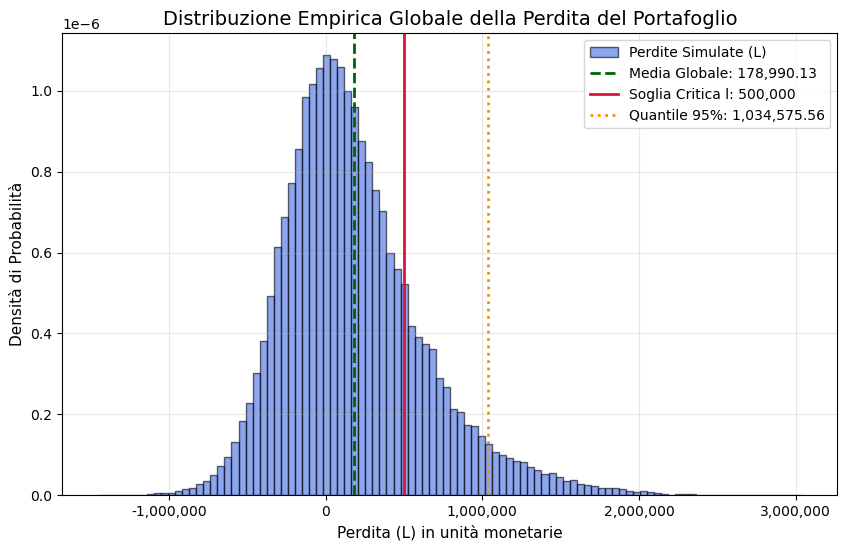

In [7]:
# 4.1 Calcolo delle statistiche descrittive ed empiriche globali
media_globale = np.mean(vettore_L)
dev_std_globale = np.std(vettore_L)
min_globale = np.min(vettore_L)
max_globale = np.max(vettore_L)

# 4.2 Calcolo dei quantili di coda (95% e 99%)
quantile_95 = np.percentile(vettore_L, 95)
quantile_99 = np.percentile(vettore_L, 99)

# 4.3 Stima empirica della probabilità di superamento della soglia (ell)
prob_superamento = np.mean(vettore_L > LA_SOGLIA)

# Creazione del dataframe riassuntivo per la visualizzazione
df_stat_globali = pd.DataFrame({
    'Metrica Riscontro': [
        'Media Empirica Globale E[L]', 
        'Deviazione Standard', 
        'Minimo Assoluto', 
        'Massimo Assoluto',
        'Quantile 95% (q_0.95)', 
        'Quantile 99% (q_0.99)',
        f'Probabilità Superamento Soglia P(L > {LA_SOGLIA:,})'
    ],
    'Valore': [
        media_globale, 
        dev_std_globale, 
        min_globale, 
        max_globale, 
        quantile_95, 
        quantile_99, 
        prob_superamento
    ]
})

print("--- STATISTICHE GLOBALI DELLA PERDITA (TAPPA 4) ---")
print(df_stat_globali.to_string(index=False, formatters={'Valore': lambda x: f"{x:,.4f}" if x <= 1 else f"{x:,.2f}"}))

# --- CONTROLLO LOGICO TAPPA 4 ---
print("\n--- CONTROLLO DI COERENZA ---")
print(f"Verifica quantile 99% > 95%: {quantile_99 > quantile_95}")
assert quantile_99 > quantile_95, "ERRORE LOGICO: Il quantile al 99% deve essere strettamente maggiore del quantile al 95%!"
assert min_globale <= media_globale <= max_globale, "ERRORE LOGICO: La media deve trovarsi tra il valore minimo e il valore massimo!"
print("Esito Controllo: OK (Proprietà della distribuzione rispettate).")

# 4.4 Rappresentazione Grafica della Distribuzione
plt.figure(figsize=(10, 6))
plt.hist(vettore_L, bins=100, density=True, alpha=0.6, color='royalblue', edgecolor='black', label='Perdite Simulate (L)')
plt.axvline(media_globale, color='darkgreen', linestyle='--', linewidth=2, label=f'Media Globale: {media_globale:,.2f}')
plt.axvline(LA_SOGLIA, color='crimson', linestyle='-', linewidth=2, label=f'Soglia Critica l: {LA_SOGLIA:,}')
plt.axvline(quantile_95, color='darkorange', linestyle=':', linewidth=2, label=f'Quantile 95%: {quantile_95:,.2f}')

plt.title('Distribuzione Empirica Globale della Perdita del Portafoglio', fontsize=14)
plt.xlabel('Perdita (L) in unità monetarie', fontsize=11)
plt.ylabel('Densità di Probabilità', fontsize=11)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.show()

## 7. Tappa 5: Analisi Condizionata e Verifica della Proprietà a Torre

In quest'ultima tappa operativa passiamo dall'analisi globale allo studio della struttura informativa del problema. Scomponiamo il vettore delle perdite $L$ in base ai tre blocchi della partizione generata dalla variabile di regime $Z$: $\mathcal{G} = \sigma(A_1, A_2, A_3)$.

L'obiettivo è duplice:
1. Stimare i singoli valori numerici delle perdite attese condizionate per ogni stato: $\mathbb{E}[L \mid A_g]$ per $g \in \{1, 2, 3\}$.
2. Verificare l'identità nota come **Legge delle Aspettative Totali**, interpretata analiticamente come un caso speciale della **proprietà a torre** delle aspettative condizionate. La proprietà a torre stabilisce che, date due strutture informative annidate $\mathcal{H} \subset \mathcal{G}$, l'aspettativa condizionata rispetto all'informazione più povera assorbe quella più ricca: $\mathbb{E}[\mathbb{E}[L \mid \mathcal{G}] \mid \mathcal{H}] = \mathbb{E}[L \mid \mathcal{H}]$. 

Nel nostro caso applicativo, l'identità viene verificata rispetto alla $\sigma$-algebra banale $\mathcal{H} = \{\emptyset, \Omega\}$ (assenza totale di informazione iniziale), dove $\mathbb{E}[L \mid \{\emptyset, \Omega\}] = \mathbb{E}[L]$. L'uguaglianza si riduce quindi alla media pesata:
$$\mathbb{E}[L] = \mathbb{E}[\mathbb{E}[L \mid \mathcal{G}]] = \sum_{g=1}^{3} \mathbb{P}(A_g) \mathbb{E}[L \mid A_g]$$

Infine, visualizziamo la scomposizione sovrapponendo le funzioni di densità empiriche condizionate per osservare graficamente come l'informazione di scenario modifichi radicalmente la distribuzione e la dispersione della perdita.

--- ANALISI CONDIZIONATA DELLA PERDITA (TAPPA 5) ---
                       Descrizione Frequenza Empirica Perdita Attesa Condizionata E[L|Ag]
Regime (Z)                                                                               
A1          Disinflazione ordinata             0.3488                          -61,279.09
A2          Inflazione persistente             0.4497                          180,917.75
A3                Repricing severo             0.2015                          590,703.71

--- VERIFICA FORMULA DEL VALORE ATTESO TOTALE ---
Media Empirica Globale (Tappa 4):        178,990.13
Media Ricomposta Ponderata (Tappa 5):    178,990.13
Scostamento Assoluto (Delta Verifica):   0.00e+00
Esito Controllo: OK (Uguaglianza verificata con successo numerico assoluto).


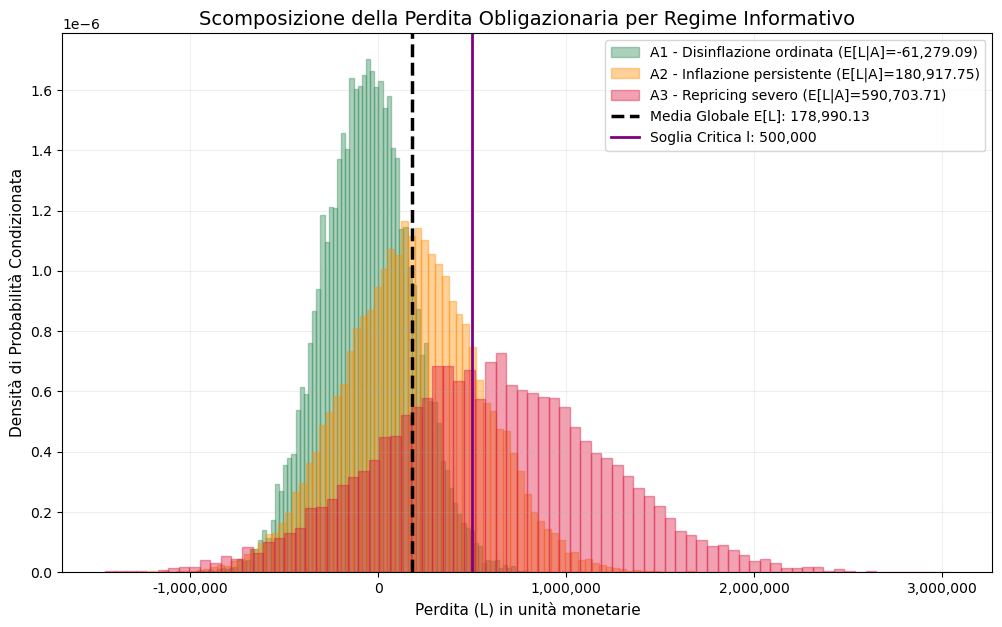

In [8]:
# 5.1 Calcolo delle medie condizionate ed estrazione statistica per blocco
medie_condizionate = {}
frequenze_stati_emp = {}

for stato in parametri_condizionati.keys():
    maschera = (vettore_Z == stato)
    medie_condizionate[stato] = np.mean(vettore_L[maschera])
    frequenze_stati_emp[stato] = np.mean(maschera)

# 5.2 Calcolo del valore atteso totale tramite scomposizione pesata
media_totale_ricomposta = sum(
    frequenze_stati_emp[stato] * medie_condizionate[stato] 
    for stato in medie_condizionate.keys()
)

# Calcolo dello scostamento (Delta) assoluto rispetto alla media globale della Tappa 4
delta_verifica = np.abs(media_globale - media_totale_ricomposta)

# Creazione del dataframe riassuntivo condizionato
df_condizionato = pd.DataFrame({
    'Regime (Z)': ['A1', 'A2', 'A3'],
    'Descrizione': ['Disinflazione ordinata', 'Inflazione persistente', 'Repricing severo'],
    'Frequenza Empirica': [frequenze_stati_emp[1], frequenze_stati_emp[2], frequenze_stati_emp[3]],
    'Perdita Attesa Condizionata E[L|Ag]': [medie_condizionate[1], medie_condizionate[2], medie_condizionate[3]]
}).set_index('Regime (Z)')

print("--- ANALISI CONDIZIONATA DELLA PERDITA (TAPPA 5) ---")
print(df_condizionato.to_string(formatters={'Frequenza Empirica': '{:.4f}'.format, 'Perdita Attesa Condizionata E[L|Ag]': '{:,.2f}'.format}))

print("\n--- VERIFICA FORMULA DEL VALORE ATTESO TOTALE ---")
print(f"Media Empirica Globale (Tappa 4):        {media_globale:,.2f}")
print(f"Media Ricomposta Ponderata (Tappa 5):    {media_totale_ricomposta:,.2f}")
print(f"Scostamento Assoluto (Delta Verifica):   {delta_verifica:.2e}")

# --- CONTROLLO NUMERICO STRINGENTE ---
# Lo scostamento deve essere nullo al netto degli arrotondamenti float di macchina
assert np.isclose(media_globale, media_totale_ricomposta), "ERRORE TEORICO: La legge delle aspettative totali non è verificata!"
print("Esito Controllo: OK (Uguaglianza verificata con successo numerico assoluto).")

# 5.3 Visualizzazione delle Densità Condizionate Sovrapposte
plt.figure(figsize=(12, 7))
colori_regimi = {1: 'seagreen', 2: 'darkorange', 3: 'crimson'}
nomi_regimi = {1: 'A1 - Disinflazione ordinata', 2: 'A2 - Inflazione persistente', 3: 'A3 - Repricing severo'}

for stato in parametri_condizionati.keys():
    maschera = (vettore_Z == stato)
    plt.hist(vettore_L[maschera], bins=80, density=True, alpha=0.4, 
             color=colori_regimi[stato], edgecolor=colori_regimi[stato],
             label=f"{nomi_regimi[stato]} (E[L|A]={medie_condizionate[stato]:,.2f})")

plt.axvline(media_globale, color='black', linestyle='--', linewidth=2.5, label=f'Media Globale E[L]: {media_globale:,.2f}')
plt.axvline(LA_SOGLIA, color='purple', linestyle='-', linewidth=2, label=f'Soglia Critica l: {LA_SOGLIA:,}')

plt.title('Scomposizione della Perdita Obligazionaria per Regime Informativo', fontsize=14)
plt.xlabel('Perdita (L) in unità monetarie', fontsize=11)
plt.ylabel('Densità di Probabilità Condizionata', fontsize=11)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
plt.grid(True, alpha=0.2)
plt.legend(fontsize=10, loc='upper right')
plt.show()